In [1]:
# !pip install python-Levenshtein

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "raw"
inject_roles = False
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
paths = get_dataset_paths(enhancement)

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)

In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

Train Loss (Epoch 1): 0.6211
Dev Eval (Epoch 1):
  exact_match: 0.0247
  precision: 0.6730
  recall: 0.6386
  f1: 0.6266
  bleu: 0.4978
  edit_distance_avg: 54.7477
  predicate_accuracy: 0.7328
  valid_logical_form_ratio: 0.9897
Train Loss (Epoch 2): 0.1706
Dev Eval (Epoch 2):
  exact_match: 0.2143
  precision: 0.8631
  recall: 0.8360
  f1: 0.8425
  bleu: 0.7229
  edit_distance_avg: 26.5457
  predicate_accuracy: 0.8945
  valid_logical_form_ratio: 0.9987
Train Loss (Epoch 3): 0.1103
Dev Eval (Epoch 3):
  exact_match: 0.3837
  precision: 0.9332
  recall: 0.9192
  f1: 0.9240
  bleu: 0.8480
  edit_distance_avg: 14.1993
  predicate_accuracy: 0.9364
  valid_logical_form_ratio: 0.9997
Train Loss (Epoch 4): 0.0772
Dev Eval (Epoch 4):
  exact_match: 0.4713
  precision: 0.9712
  recall: 0.9651
  f1: 0.9670
  bleu: 0.8995
  edit_distance_avg: 7.2107
  predicate_accuracy: 0.9644
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 5): 0.0575
Dev Eval (Epoch 5):
  exact_match: 0.5363
  precision: 0

Predictions saved to: /notebooks/meta-semantic-research/predictions/raw/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/raw/t5-small_test_metrics.csv
Test Eval:
  exact_match: 0.0000
  precision: 0.9854
  recall: 0.9770
  f1: 0.9805
  bleu: 0.4921
  edit_distance_avg: 9.5933
  predicate_accuracy: 0.9770
  valid_logical_form_ratio: 0.9997


,exact_match,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.00%,98.54%,97.70%,98.05%,49.21%,9.59,97.70%,99.97%


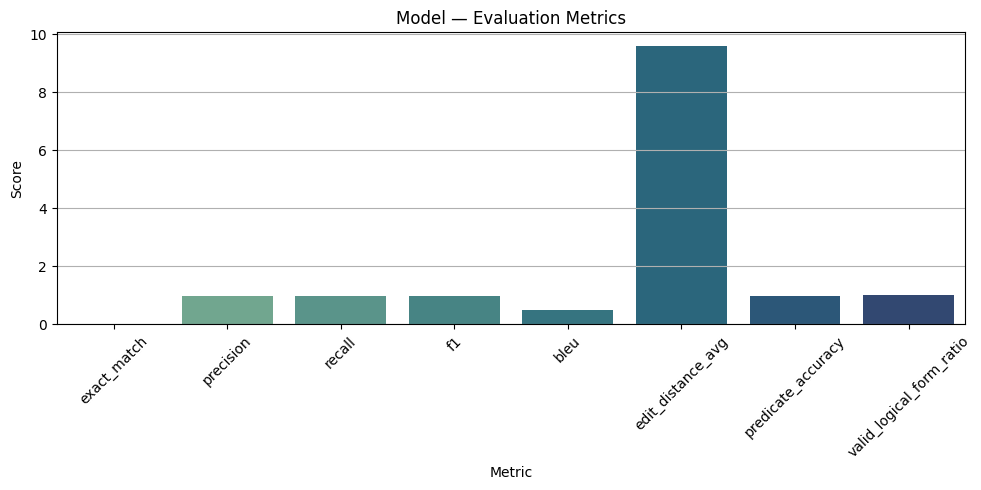

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/raw/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/raw/t5-small_gen_metrics.csv
Gen Eval:
  exact_match: 0.0000
  precision: 0.9671
  recall: 0.8914
  f1: 0.9166
  bleu: 0.4111
  edit_distance_avg: 60.1330
  predicate_accuracy: 0.9249
  valid_logical_form_ratio: 0.9992


,exact_match,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.00%,96.71%,89.14%,91.66%,41.11%,60.13,92.49%,99.92%


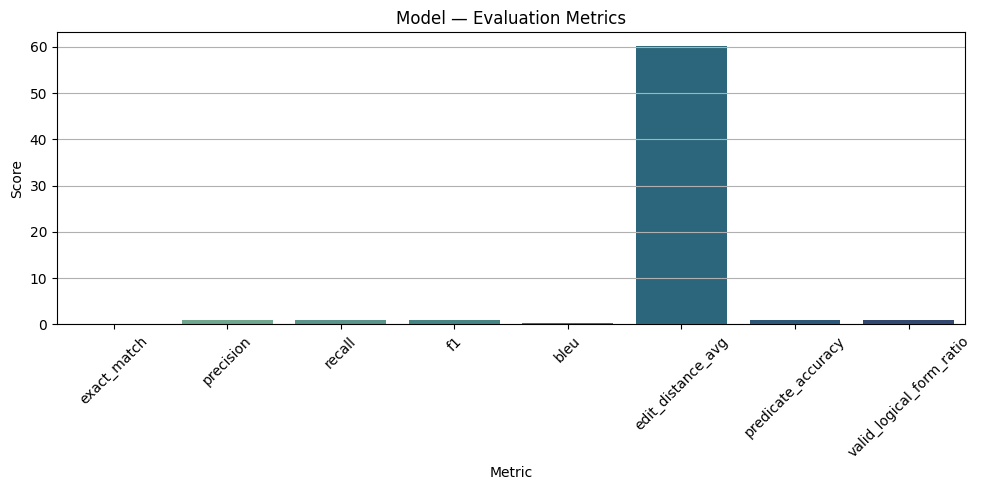

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

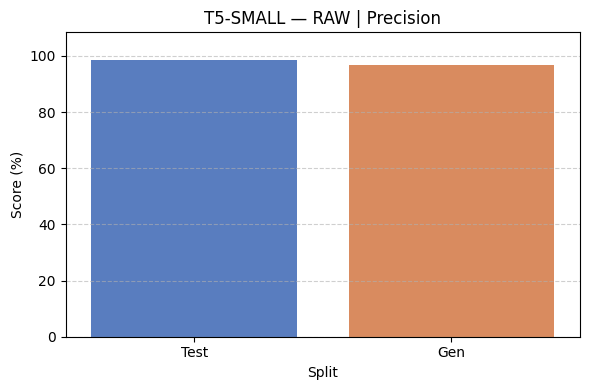

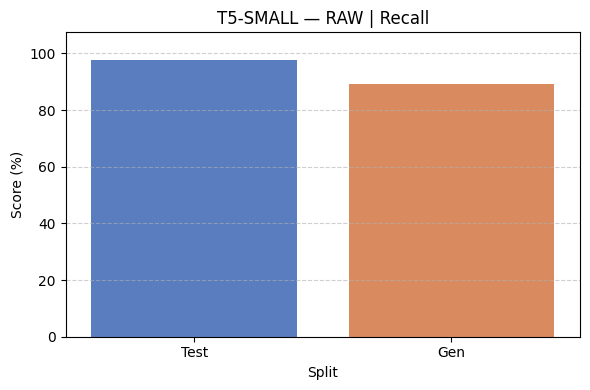

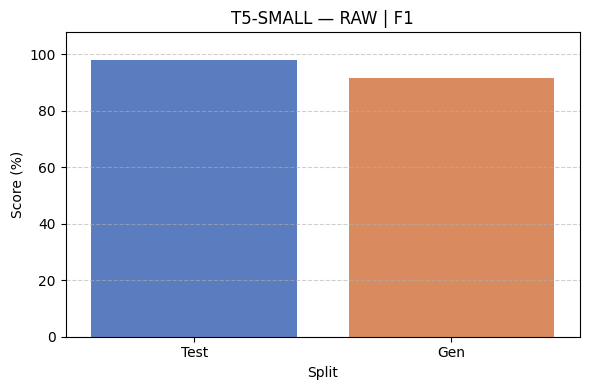

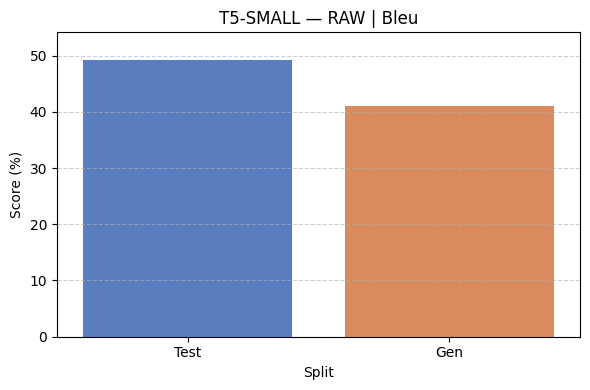

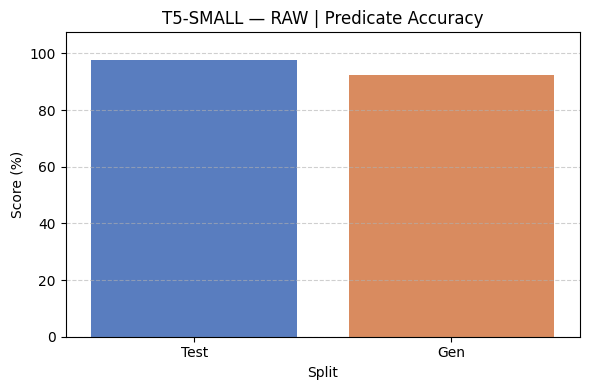

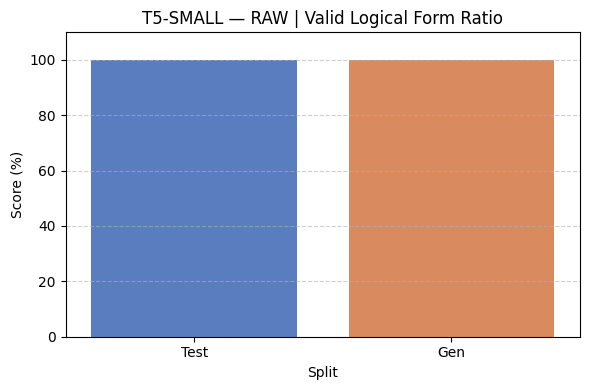

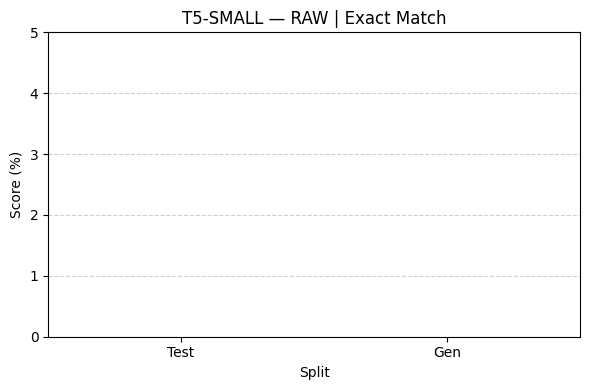

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)